# Environment Setup

Kaggle challenge: 
 [SPR X-Ray Gender Prediction Challenge](https://www.kaggle.com/competitions/spr-x-ray-gender/data?select=sample_submission_gender.csv)

To ensure this notebook runs in a clean and consistent environment, follow these steps **in your terminal (outside the notebook)**:

1. Create a new conda environment: `conda create -n xray-gender-pred python=3.9 -y`

2. Activate the environment: `conda activate xray-gender-pred`

3. Install required packages: 
- Core libraries: `conda install numpy pandas scikit-learn matplotlib ipython jupyter -y`
- PyTorch (for Mac M1 with Metal Performance Shaders): `pip install torch torchvision torchaudio tqdm`
Note: After activating your conda environment, you’re installing PyTorch inside that conda environment. 


4. Link the environment to Jupyter (register your new environment as a kernel in Jupyter Notebook): `python -m ipykernel install --user --name xray-gender-pred --display-name "Python (xray-gender-pred)`

5. Open Jupyter Notebook and select the kernel: 
- In your Jupyter Notebook interface: Select Kernel → Python Environments → xray-gender-pred
- Once the correct kernel is selected, Jupyter will switch the notebook kernel to this environment, and you're ready to run the notebook!

💡 **Tip**: To ensure your environment includes *all* required packages exactly as used in this project, you can also download and create the environment directly from the provided `environment.yml` file in the [GitHub repo](#) using:  
> `conda env create -f environment.yml`  
> This is the most reliable way to replicate the project setup.

*Note: If you install a new library while your Jupyter kernel is running (in the terminal), it becomes immediately available to that kernel once you import it. A restart is usually not needed, but may help in some cases.*

In [1]:
# Environment Check: to confirm you're running the notebook using the Python interpreter inside the xray-gender-pred conda environment.
import sys
sys.executable

'/Users/mac/anaconda3/envs/xray-gender-pred/bin/python'

# Imports and Dependencies 

In [2]:
# Core libraries
import sys
import platform
import random
import math

# Display
from IPython import display

# Data handling
import numpy as np
import pandas as pd

# Machine learning & statistics
import torch
from torch import nn, optim

import sklearn
from sklearn import datasets, metrics, model_selection, tree
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
# Print system and package info
print(f"Python Platform: {platform.platform()}")
print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")

Python Platform: macOS-15.6-arm64-arm-64bit
Python Version: 3.9.23 (main, Jun  5 2025, 08:49:36) 
[Clang 14.0.6 ]
PyTorch Version: 2.7.1
Pandas Version: 2.3.1
Scikit-Learn Version: 1.6.1


## Setting Up Device-Agnostic Code (CPU / CUDA / Apple M1)

This section ensures the model runs on the best available hardware accelerator:

- **CUDA**: A parallel computing platform by NVIDIA that enables GPU acceleration on compatible NVIDIA devices.
- **MPS**: Metal Performance Shaders, Apple’s kernels that are fine-tuned for the unique characteristics of each Metal GPU family for GPU computations on Apple Silicon (M1/M2). 
- **CPU**: The processor used when no GPU is available, slower but universally compatible. 

By writing device-agnostic code, we ensure the script can run efficiently across diverse systems (Windows/Linux/macOS) without requiring manual hardware configuration.

💡 Since I’m using a Mac with an Apple M1 chip, the setup I used follows the approach outlined in this tutorial: [Installing PyTorch on Apple M1 chip with GPU Acceleration](https://towardsdatascience.com/installing-pytorch-on-apple-m1-chip-with-gpu-acceleration-3351dc44d67c/). 


In [4]:
# Check if CUDA (NVIDIA GPU) is available
has_cuda = torch.cuda.is_available()

# Check if MPS (Apple Metal GPU) is available 
has_mps = torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False    # if it does not work -> do tihs instead - which worked in the past - getattr(torch, 'has_mps', False)
  # Note: If mps doesn't exist at all (e.g., on older PyTorch versions or non-macOS systems), then don't crash, just return False.

# Decide on the best available device
if has_cuda:                                                  # Check if CUDA (GPU) is available
    num_gpus = torch.cuda.device_count()                      # Detects the number of available GPUs
    print(f"Number of available GPUs: {num_gpus}")      
    device = torch.device("cuda:0")                           # Selects the first GPU as the active device
    print(f"✅ Using CUDA: {torch.cuda.get_device_name(0)}")  # Prints the name of the GPU being used


elif has_mps:
    device = torch.device("mps")   # Use Apple M1/M2 GPU
    print("✅ Using Apple MPS (Metal Performance Shaders)")

else:
    device = torch.device("cpu")                              # Fallback to CPU
    print("CUDA and MPS not available. Using CPU")


# Optional: print device name for clarity
print(f"📦 Target device: {device}")

✅ Using Apple MPS (Metal Performance Shaders)
📦 Target device: mps


# Load and Preprocess data
- Load your dataset into memory, and perform any necessary preprocessing steps. 
- 🔗 Download the dataset: [Kaggle: SPR X-Ray Gender Classification](https://www.kaggle.com/competitions/spr-x-ray-gender/data)

> 📦 **Note:** The folder is approximately **21.32 GB** in size.

In [5]:
# Loading the dataset into a Pandas Dataframe (the data is already divided into train test and validate)

# Specify the directory where your images are located
data_dir = '/Volumes/Aya/spr-x-ray-gender/kaggle/kaggle'

In [6]:
import os             # os is a built-in Python module for interacting with the operating system.

# Get the list of subdirectories (train, test)
subdirectories = ['train', 'test']

# Create an empty dictionary to store the loaded images
loaded_images = {}

# Iterate over the subdirectories
for subdirectory in subdirectories:
    # Create an empty dictionary for the current subdirectory
    subdirectory_images = {}

    # Get the path to the current subdirectory
    subdirectory_path = os.path.join(data_dir, subdirectory)

    # Store the paths for later use 
    if subdirectory == 'train':
        train_dir = subdirectory_path
    elif subdirectory == 'test':
        test_dir = subdirectory_path

    # Create a list to store images from the current subdirectory
    image_list = []

    # Iterate over the files in the subdirectory subfolder
    for filename in os.listdir(subdirectory_path):
        # Get the path to the current image file
        image_path = os.path.join(subdirectory_path, filename)

        # Append the loaded image to the image_list
        image_list.append(image_path)

    # Add the subdirectory_images dictionary to the loaded_images dictionary with the subdirectory name as the key
    loaded_images[subdirectory] = image_list


In [7]:
loaded_images['train'][0]

'/Volumes/Aya/spr-x-ray-gender/kaggle/kaggle/train/000000.png'

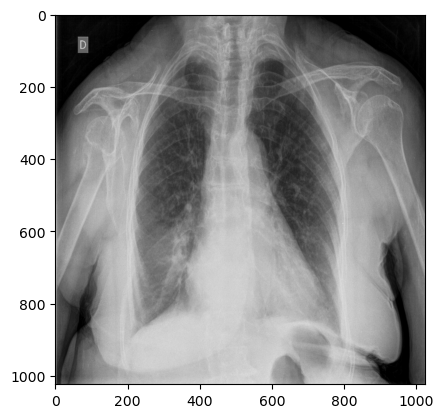

In [8]:
from PIL import Image # Image is a module within PIL (Python Imaging Library Image) and it's used for loading, manipulating, and saving image files.

image = Image.open(loaded_images['train'][0])
plt.imshow(image)

## Getting the training labels

In [9]:
train_gender_data = pd.read_csv('/Volumes/Aya/spr-x-ray-gender/train_gender.csv') 

In [10]:
train_gender_data

,imageId,gender
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0
...,...,...
10697,10697,0
10698,10698,0
10699,10699,1
10700,10700,0


The file `train_gender.csv` contains the labels (`gender` column) for the training set and the corresponding `ImageId` (`imageId` column).  
We will extract the labels and store them in a variable called `train_labels`.

In [11]:
# let's get the gender column from the train_gender_data corresponding to our train labels
train_labels = train_gender_data['gender']

In [12]:
y_train = train_labels

In [13]:
y_train

0        0
1        0
2        1
3        1
4        0
        ..
10697    0
10698    0
10699    1
10700    0
10701    1
Name: gender, Length: 10702, dtype: int64

In order to have the labels corresponding to their respective images, we sort loaded_images['train'] so they correspond to the ordering of the labels in y_train. 

In [14]:
# sorting the training and testing images to correspond to the order of the labels 
loaded_images['train'] = sorted(loaded_images['train'])
loaded_images['test'] = sorted(loaded_images['test'])

**Purpose of this check:**

This cell bellow ensures that all the images referenced in `y_train` exist in the training image folder. It compares the expected image filenames (based on the label indices) to the actual loaded image paths. If any image is missing, it may indicate a download or preprocessing issue that must be resolved before moving forward. 


In [15]:
# Generate expected filenames based on label indices 
expected_train_images = [               # list of the image filenames we expect based on the index of y_train
    os.path.join(train_dir, f"{i:06d}.png") for i in y_train.index
]

# note: f"{i:06d}.png" makes sure the filename string matches the dataset's naming convention exactly (e.g. instead of 1 -> '000001') [ 0 → pad with leading zeroes; 6 → total width of the number should be 6 digits; d → treat the number as an integer ] 

# Check if any expected image is not in loaded_images['train']
missing_images_for_labels = [           # list of the image files that are missing, but should exist for labels
    fname for fname in expected_train_images if fname not in loaded_images['train']
]

# Display what we found 
if missing_images_for_labels:
    print(f"{len(missing_images_for_labels)} image(s) expected are missing:")
    for m in missing_images_for_labels:
        print(m)
else:
    print("All images referenced in y_train are present.")


1 image(s) expected are missing:
/Volumes/Aya/spr-x-ray-gender/kaggle/kaggle/train/002719.png


In [16]:
y_train = y_train.drop(2719)
y_train = y_train.reset_index(drop=True)

Note the challenge only provided the labels for the training set (y_train), there is no y_test (as it is a still active challenge they did not share the testing labels.)

# Exploratory Data Analysis (EDA)
In this section, we explore the data to gain insights about the distribution of features, correlation between features, and identify any patterns or trends in the data.

## Data distribution 

In [17]:
len(loaded_images['test'])

11746

In [18]:
len(loaded_images['train'])

10701

In [19]:
class_name = ['train', 'test']  # Define the two dataset splits

# Calculate the total number of images across both splits
total_images = len(loaded_images['test']) + len(loaded_images['train'])

# Calculate the percentage of images in the training set
train_percentage = len(loaded_images['train']) / total_images

# Calculate the percentage of images in the test set
test_percentage = len(loaded_images['test']) / total_images

# Print the percentage of training and test images
print(f"Train percentage: {train_percentage}")
print(f"Test percentage: {test_percentage}")

Train percentage: 0.4767229473871787
Test percentage: 0.5232770526128213


### Distribution of gender accross the training set

In [20]:

# Convert y_train to a pandas Series
y_train_series = pd.Series(y_train)

# Count the number of occurrences of each gender
gender_counts = y_train_series.value_counts()

# Create a dataframe with gender and count columns
gender_distribution = pd.DataFrame({'Gender': ['Female', 'Male'], 'Count': gender_counts})

# Set the Gender column as the index
gender_distribution.set_index('Gender', inplace=True)

# Print the gender distribution table
print("Gender Distribution for Training Set:")
print(gender_distribution)

Gender Distribution for Training Set:
        Count
Gender       
Female   6208
Male     4493


Based on the gender distribution, it appears that the training data is a bit biased towards the "Female" gender, as there are 6,209 samples labeled as "Female" and 4,493 samples labeled as "Male". This suggests that there are more examples of the "Female" gender compared to the "Male" gender in the training data. 

# Preprocess the data

* Normalize pixel values: Convert the pixel values of the images to a common scale, typically between 0 and 1.
You can achieve this by dividing the pixel values by the maximum pixel value, such as 255, assuming the images are in the 8-bit range.
Resize the images:

* Resize the images to a consistent size that is suitable for your CNN architecture.
Consider the computational resources available and strike a balance between image resolution and memory requirements.
Resizing can be done using libraries like OpenCV or the resize() function in Python's PIL (Python Imaging Library).

* Convert the images to NumPy arrays: 
CNNs typically expect input data in the form of NumPy arrays.
Convert the preprocessed images to NumPy arrays using libraries like NumPy or OpenCV.

> **Notice about running the cell bellow:** 
1. Make sure opencv is installed in your environment (in our case `xray-gender-pred`), you can used the command: `conda install -c conda-forge opencv`. 
2. The cell bellow takes a while to run (in the last run it took around: 15mins). 
3. Occasionally, the kernel crashes during execution, make sure you restart the kernel and run all the cells again. 

In [21]:
%%time      
# Measures and prints the execution time of the entire cell.

import cv2

# Preprocessing steps
def preprocess_images(image_paths):
    images = [] # initialising an empty list 
    for path in image_paths:
        img = cv2.imread(path, 0)               # Load image in grayscale
        if img is None:         # In order to know which images failed to load 
            print (f"Failed to load image: {path}")
            continue            # skip over them instead of crashing
        img = img / 255.0                       # Normalize pixel values between 0 and 1
        img = cv2.resize(img, (224, 224))       # Resize image to (224, 224)
        images.append(img)
    preprocessed_images = np.array(images)      # Convert images to NumPy array
    return preprocessed_images

# Preprocess training images
train_image_paths = loaded_images['train']      # Assuming loaded_images['train'] contains image paths
train_images = preprocess_images(train_image_paths)

# Preprocess test images
test_image_paths = loaded_images['test']        # Assuming loaded_images['test'] contains image paths
test_images = preprocess_images(test_image_paths)


print(len(test_images))
print(len(train_images))
print(len(y_train))

11746
10701
10701
CPU times: user 5min 12s, sys: 33 s, total: 5min 45s
Wall time: 12min 49s


Now we have the images as NumPy arrays and the shape of the preprocessed images will be (num_images, 224, 224). 

# Train Validation Split

We are only given `train_gender.csv` (the training set containing two columns; the image id and gender), and `sample_submission_gender.csv` (a sample submission file also containing two columns) and we don't have the test labels. Thus, we will split the provided training data (X_train and y_train) into training and validation sets (80% and 20%). This will allow to evaluate the performance of the model during training and make predictions on the test data for the challenge.

N.B: Even if the size of the test set is 11747 and the training 10702, we have to keep the test set completely separate until we have completed the model training and tuning process.

> **Notice about running the cell bellow:** It takes a while to run (took 54 seconds in my last run).

In [22]:
%%time

# Split the data before tuning and training
X_train, X_val, y_train, y_val = train_test_split(
    train_images , 
    y_train, 
    test_size=0.2, 
    stratify=y_train,           # When you split the data into training and validation sets, make sure both sets have the same proportion of class labels (i.e., same % of males and females).
    random_state=42
)

# Get the shape (number of samples and dimensions) of the training and validation data and print them 
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)

Training data shape: (8560, 224, 224)
Validation data shape: (2141, 224, 224)
Training labels shape: (8560,)
Validation labels shape: (2141,)
CPU times: user 228 ms, sys: 4.61 s, total: 4.83 s
Wall time: 49.9 s


# Model Deveploment 
Task : Predicting gender from Chest X rays. 


Steps: 

1. Design the CNN Architecture: define the model structure (GenderDetectionCNN) and send it to the device.

2. Set Up the Loss Function and Optimizer: You define these with an initial learning rate, but we won’t know the best lr yet, tuning comes next.

3. Create the Data Loaders for both training and validation. 

4. Training Loop + Tuning the Learning Rate
  - Train using a few candidate lr values. 
  - Record training/validation loss per epoch. 
  - Plot learning curves. 
  - Choose the lr that gives best validation performance (i.e., doesn't overfit or underfit). 
  - Note: 
    - In practice, it’s better to report performance only on validation, and use test set strictly once.
    - We could tune using different hyperparameters - for simplicity we only focus on LR here... 

5. Final Step: Inference 
  - Use the trained model to predict on test_images
  - Store predictions in CSV (e.g., image filename + predicted label)

## ✅ Design the CNN architecture:

Goal: 
* Select an appropriate CNN architecture for your task. This can include stacking convolutional layers, pooling layers, and optionally adding dropout layers for regularization.
* Experiment with different network depths, filter sizes, and activation functions to find the best configuration for your dataset.

In this step, I explored multiple CNN architectures to evaluate performance, stability, and hardware compatibility—particularly with Apple M1's Metal acceleration backend. This involved:

- **Iterative design testing**: trying out different combinations of convolutional layers, kernel sizes, and pooling strategies
- **Dimensionality tuning**: adapting the shape of the flattened tensor to match the fully connected layers
- **Hardware troubleshooting**: identifying architectures that caused kernel crashes on specific hardware (e.g., excessive memory usage on M1 chip)
- **Stability and generalization checks**: ensuring the model could train consistently without runtime issues

Only the final, stable architecture is included in this version of the codebase. Earlier variations were removed to maintain clarity and professionalism, but they played a key role in guiding the design process. 

The expected shape of the input tensor for this code is [batch_size, 1, 224, 224]: 
* batch_size refers to the number of samples in a batch.
* 1 represents the number of input channels (grayscale images have 1 channel).
* 224 is the height and width of the input images.

The input tensor should have the same shape as the input images provided to the model during training or inference. Each image should be a grayscale image with a height and width of 224 pixels. 

In [23]:
# Expected input format: [batch_size, num_input_channels, height, width]

import torch.nn as nn

class GenderDetectionCNN(nn.Module):
    def __init__(self):
        super(GenderDetectionCNN, self).__init__()

        # Convolutional feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # First conv layer: 1 input channel → 16 output channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Downsamples to 112x112
            nn.Dropout2d(p=0.25),                                  # dropout added (to combat overfitting)

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), # Second conv layer: 16 → 32 channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Downsamples to 56x56
            nn.Dropout2d(p=0.25),                                  # dropout added (to combat overfitting)
        )

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 56 * 56, 256),  # Flattened input from conv output
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)              # Output: 2 classes (e.g., male vs female)
        )

    def forward(self, x):
        x = self.features(x)               # Pass through convolutional layers
        x = x.view(x.size(0), -1)          # Flatten tensor for the linear layer
        x = self.classifier(x)             # Pass through fully connected layers
        return x


- The `self.features` sequence contains two convolutional layers with ReLU activation and max pooling operations. These layers are responsible for extracting features from the input images.

- The `self.classifier` sequence consists of fully connected layers. The first linear layer takes the flattened output of the last convolutional layer as input and applies ReLU activation. Dropout regularization is applied after the first linear layer to prevent overfitting. The final linear layer produces the output logits for the two gender classes (female and male).

- The `forward` method defines the forward pass of the model. It passes the input `x` through the feature extraction layers (`self.features`), reshapes the output, and then passes it through the classification layers (`self.classifier`) to produce the predicted logits.

Overall, the model architecture is suitable for the gender detection task with 2 classes. However, it's important to note that the effectiveness of the model depends on factors such as the quality and size of the dataset, the training procedure, and the specific requirements of the task.

In [24]:
# Create an instance of the GenderDetectionCNN model and send it to target device
model = GenderDetectionCNN().to(device)
model

GenderDetectionCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)

## ✅ Set Up the Loss Function and Optimizer

Note: Recall a loss function is what measures how wrong your model predictions are, the higher the loss, the worse your model. Also, PyTorch documentation often refers to loss functions as "loss criterion" or "criterion", these are all different ways of describing the same thing.

In [25]:
loss_fn = nn.CrossEntropyLoss() 

- Why `BCEWithLogitsLoss`? 
  - Because in our model, the final Linear(256, 2) outputs 2 logits per sample, one for each class (female, male). 
    •	These are raw logits, not probabilities
    •	Your labels are integers: 0 (female) or 1 (male)

In [26]:
# reusable function to initailize model and optimizer 
def initialize_model_and_optimizer (lr: float):
  model = GenderDetectionCNN().to(device)  
  print ("Model used:\n", model)                                    # type: torch.nn.Module 

  optimizer = torch.optim.SGD(model.parameters(), lr = lr)          # type: torch.optim.Optimizer 
  print (f"Optimizer used: {optimizer}\n")
  print (f"Learning Rate used: {lr}")
  return model, optimizer                                           # we are returning a Tuple[torch.nn.Module, torch.optim.Optimizer] 


- Why `torch.optim.SGD`? 
   - I chose Stochastic Gradient Descent (SGD) mainly because of its memory efficiency. Since SGD updates the parameters for each training example one at a time, it is memory-efficient and can handle large datasets that cannot fit into memory. [reference](https://klu.ai/glossary/stochastic-gradient-descent)

## ✅ Create the Data Loaders for both training and validation. 
Data loaders are for loading data in batches during training. We will use PyTorch's DataLoader class for this purpose. 

> **Notice about running the cell bellow:** It takes a while to run (took 24 seconds in my last run).

In [27]:
# Checking for missing values in X_train and y_train:
print(np.isnan(X_train).sum())
print(np.isnan(y_train).sum())

0
0


No missing values 

In [28]:
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train: (8560, 224, 224)
Shape of y_train: (8560,)


- y_train is a 1-dimensional array with 8561 elements. 
- X_train is NumPy array with shape (8560, 224, 224). 

In [29]:
from torch.utils.data import TensorDataset, DataLoader

x_train_tensor = torch.from_numpy(X_train)      # Convert the NumPy array of training images to a PyTorch tensor
y_train_tensor = torch.tensor(y_train.values)   # Convert the pandas Series of training labels to a PyTorch tensor

# same for validation
x_val_tensor = torch.from_numpy(X_val) 
y_val_tensor = torch.tensor(y_val.values) 

In [30]:
# Reshape the tensors to match the expected input shape of the CNN model
x_train_tensor = x_train_tensor.unsqueeze(1)      # Add a channel dimension
x_val_tensor = x_val_tensor.unsqueeze(1)          # Add a channel dimension

In [31]:
x_train_tensor.shape

torch.Size([8560, 1, 224, 224])

Now the shape of x_train_tensor (torch.Size([8561, 1, 224, 224])) matches the expected shape for our model([batch_size, 1, 224, 224]).

In [32]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)   # Create a TensorDataset for train data 
val_dataset   = TensorDataset(x_val_tensor, y_val_tensor)         # Create a TensorDataset for validation data

In [33]:
batch_size = 16  # batch_size is the number of samples per batch (to be adjusted as needed)

train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader    = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Note: 
  - `num_workers>0`	means data loading is done in multiple subprocesses (faster), however, especially in Mac OS it can sometimes cause crashes due to how multiprocessing works. If you run into issues, just set: `num_workers=0` 
  - Why are we not shuffling for the validation? 
    - We use validation to track model performance across epochs by comparing different hyperparameter settings and spotting overfitting/underfitting patterns. Thus, shuffling would not be helpful as we're not updating weights using validation data (no backpropagation) and the order doesn’t affect the outcome as all samples will be evaluated anyway (unlike for training where shuffling introduces randomness to avoid overfitting to sample order). In sum, keeping the order fixed for validation ensures reproducibility and stable metrics across runs.

We created a data loader for the training and validation sets that:
  - loads data in mini-batches of `batch_size`
  - shuffles the data at each epoch for better generalization
  - uses `num_workers` subprocesses to load data in parallel

Note: the `DataLoader` handles batching automatically, so when you loop over it during training, you’re working batch by batch.

## Training Loop + Tuning 
During each training iteration (i.e., processing one batch), the model performs a forward pass, computes the loss, backpropagates the gradients, and updates its weights. Once all batches have been processed, one full epoch is complete; meaning the model has seen the entire training dataset once.

In [34]:
# Check shape of a single batch for both training and validation
first_batch_train = next(iter(train_loader))
images_train, labels_train = first_batch_train

first_batch_val = next(iter(val_loader))
images_val, labels_val = first_batch_val

print ("Sample batch type and shape for training:")
print ("Images shape:", images_train.shape)             # Should be [batch_size, 1, 224, 224]
print ("Images type:", type(images_train))              # expect <class 'torch.Tensor'> 
print ("Labels shape:", labels_train.shape)             # Should be [batch_size]
print ("Labels type:", type(labels_train))              

print ("\n")
print ("Sample batch type and shape for validation:")
print ("Images shape:", images_val.shape)               # Should be [batch_size, 1, 224, 224]
print ("Images type:", type(images_val))                # expect <class 'torch.Tensor'> 
print ("Labels shape:", labels_val.shape)               # Should be [batch_size]
print ("Labels type:", type(labels_val))              

print ("\n")
print ("Total number of batches for training and validation:")
print (f"In train_loader: {len(train_loader)}")
print (f"In val_loader: {len(val_loader)}")

Sample batch type and shape for training:
Images shape: torch.Size([16, 1, 224, 224])
Images type: <class 'torch.Tensor'>
Labels shape: torch.Size([16])
Labels type: <class 'torch.Tensor'>


Sample batch type and shape for validation:
Images shape: torch.Size([16, 1, 224, 224])
Images type: <class 'torch.Tensor'>
Labels shape: torch.Size([16])
Labels type: <class 'torch.Tensor'>


Total number of batches for training and validation:
In train_loader: 535
In val_loader: 134


In [35]:
# initialize 
train_losses_per_epoch = []        # list storing average training loss per epoch
val_losses_per_epoch = []          # list storing average validation loss per epoch
train_accuracies_per_epoch = []    # list storing average training accuracy per epoch
val_accuracies_per_epoch = []      # list storing average validation accuracy per epoch

# Setting the number of epochs 
num_epochs = 20

# Reinitialize model and optimizer if needed
lr = 0.01
model, optimizer = initialize_model_and_optimizer(lr)


Model used:
 GenderDetectionCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
Optimizer used: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Learning Rate used: 0.01


> **Notice about running the cell bellow:** It takes a while to run (took 25 mins in my last run).

In [36]:
%%time 

import matplotlib.pyplot as plt     # Library for plotting graphs
import torch.nn.functional as F     # Functional interface for loss functions like cross_entropy

# Training and validation loop for multiple epochs
for epoch in range(num_epochs):
    model.train()               # Set the model to training mode 

    epoch_train_loss = 0.0      # Initialize total training loss for this epoch
    correct_train = 0           # Count of correct predictions during training
    total_train = 0             # Total number of training samples seen so far

    # -------------------- -------------------- TRAINING  -------------------- --------------------

    # Loop over all batches in the training DataLoader
    for batch_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()                   # Clear previous gradients before backpropagation

        images = images.float()                 # Convert the input data to float32 (PyTorch DataLoader doesn't guarantee that tensors will be float32 unless you explicitly convert them each time)
        labels = labels.long()                  # Convert label tensors to long (int64), required by cross_entropy

        images = images.to(device)              # Move images to device 
        labels = labels.to(device)              # Move labels to device

        outputs = model(images)                 # Forward pass: compute model predictions

        # Compute training loss 
        train_loss_per_batch = loss_fn(outputs, labels)   # Use cross-entropy loss for multi-class classification
        train_loss_per_batch.backward()                     # Backward pass: compute gradients
        optimizer.step()                                    # Update model weights using optimizer

        epoch_train_loss += train_loss_per_batch.item()     # Add scalar float loss from this batch (Accumulated loss across batches)
        _, predicted = torch.max(outputs.data, 1)           # Get predicted class (finds the index of the higher score, and that index corresponds to the predicted class (e.g., 0 = female, 1 = male)
        total_train += labels.size(0)                       # incrementing total_train by how many samples we saw in current batch (which is labels.size(0))
        correct_train += (predicted == labels).sum().item() # Count how many predictions were correct

    # now epoch_train_loss holds the sum of all batch losses in that epoch 
    
    # Calculate the average training loss and accuracy for the epoch
    epoch_train_loss /= len(train_loader)                   # divide total loss by number of batches
    epoch_train_accuracy = correct_train / total_train

    # Save losses and accuracies to track progress over epochs
    train_losses_per_epoch.append(epoch_train_loss)
    train_accuracies_per_epoch.append(epoch_train_accuracy)

    # -------------------- -------------------- VALIDATION -------------------- --------------------

    model.eval()        # Set the model to evaluation mode (disables dropout, etc.)

    with torch.no_grad():       # Even though we're not updating weights during validation, PyTorch still tracks operations for autograd by default, unless we tell it not to -> saves memory. 
        
        epoch_val_loss = 0.0    # Total validation loss for the epoch 
        predicted_labels = []   # Store all predicted labels (for confusion matrix or plotting)
        true_labels = []        # Store all true labels
        correct_val = 0         # Number of correct predictions on validation set
        total_val = 0           # Total number of validation samples
        

        # Loop over all batches in the validation DataLoader
        for batch_idx, (images, labels) in enumerate(val_loader):
            images = images.float()     # Convert validation images to float
            labels = labels.long()      # Convert validation labels to long

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)     # Forward pass on validation data

            val_loss_per_batch = loss_fn(outputs, labels)             # Compute validation loss
            epoch_val_loss += val_loss_per_batch.item()               # Accumulate validation loss

            _, predicted = torch.max(outputs.data, 1)                 # Get predicted class for each input
            total_val += labels.size(0)                               # Count validation samples
            correct_val += (predicted == labels).sum().item()         # Count correct predictions
            
            predicted_labels.extend(predicted.tolist())               # Save predictions 
            true_labels.extend(labels.tolist())                       # Converts the labels tensor to a Python list, then  adds those values to true_labels

            # By the end of validation, true_labels will contain the full list of ground-truth labels for the entire validation set, which we will later compare to predicted_labels.

            # Free up memory by deleting intermediate variables
            del images
            del labels
            del outputs
            torch.cuda.empty_cache()        # Optional: clears unused memory on GPU

        epoch_val_loss /= len(val_loader)               # Average validation loss
        epoch_val_accuracy = correct_val / total_val    # Validation accuracy

    # Print the validation accuracy and loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Accuracy: {epoch_val_accuracy:.4f}, Validation Loss: {epoch_val_loss:.4f}")

    # Save losses and accuracies to track progress over epochs
    val_losses_per_epoch.append(epoch_val_loss)
    val_accuracies_per_epoch.append(epoch_val_accuracy)



##### to do - FIX THE ORDER of SECTIONS - check GPT window


Epoch 1/20, Validation Accuracy: 0.7646, Validation Loss: 0.5169
Epoch 2/20, Validation Accuracy: 0.7795, Validation Loss: 0.4757
Epoch 3/20, Validation Accuracy: 0.7823, Validation Loss: 0.4688
Epoch 4/20, Validation Accuracy: 0.8169, Validation Loss: 0.4192
Epoch 5/20, Validation Accuracy: 0.8375, Validation Loss: 0.3998
Epoch 6/20, Validation Accuracy: 0.8188, Validation Loss: 0.3936
Epoch 7/20, Validation Accuracy: 0.8580, Validation Loss: 0.3576
Epoch 8/20, Validation Accuracy: 0.8501, Validation Loss: 0.3731
Epoch 9/20, Validation Accuracy: 0.8688, Validation Loss: 0.3370
Epoch 10/20, Validation Accuracy: 0.8631, Validation Loss: 0.3239
Epoch 11/20, Validation Accuracy: 0.8795, Validation Loss: 0.3015
Epoch 12/20, Validation Accuracy: 0.8758, Validation Loss: 0.2947
Epoch 13/20, Validation Accuracy: 0.8664, Validation Loss: 0.3092
Epoch 14/20, Validation Accuracy: 0.8968, Validation Loss: 0.2758
Epoch 15/20, Validation Accuracy: 0.8977, Validation Loss: 0.2750
Epoch 16/20, Valida

STEPS TO FOLLOW: 
  - Loss & Accuracy over Epochs (keep this)
    One plot showing:
    - train_losses_per_epoch
    - val_losses_per_epoch
    - train_accuracies_per_epoch
    - val_accuracies_per_epoch

  - If you want to include them, do it for validation only — no need to plot them for training -> val_precisions_per_epoch... 📌 Or just print their final values at the end of training and explain why they matter.
    - A SECOND PLOT showing:
      - val_precisions_per_epoch - val_recalls_per_epoch - val_f1s_per_epoch


  - CONFUSION matrix: Best practice: show confusion matrix for your best model only (not every epoch — that gets messy) -> oNE TIME



### Learning curve 
Monitor the training process by observing the loss and accuracy metrics on both the training and validation sets.
Adjust hyperparameters and network architecture as needed to improve performance.

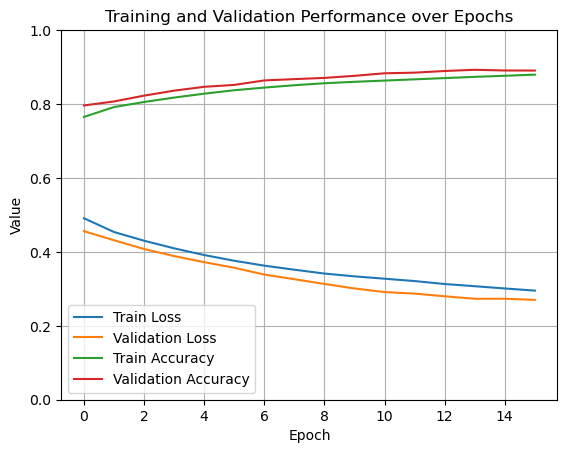

<Figure size 640x480 with 0 Axes>

In [37]:
# Smooth the curves using moving averages
smooth_train_losses = []
smooth_val_losses = []
smooth_train_accuracies = []
smooth_val_accuracies = []

window_size = 5

for i in range(len(train_losses_per_epoch) - window_size + 1):
    smooth_train_losses.append(sum(train_losses_per_epoch[i:i+window_size]) / window_size)
    smooth_val_losses.append(sum(val_losses_per_epoch[i:i+window_size]) / window_size)
    smooth_train_accuracies.append(sum(train_accuracies_per_epoch[i:i+window_size]) / window_size)
    smooth_val_accuracies.append(sum(val_accuracies_per_epoch[i:i+window_size]) / window_size)

# Plotting the loss and accuracy curves
plt.plot(smooth_train_losses, label='Train Loss')
plt.plot(smooth_val_losses, label='Validation Loss')
plt.plot(smooth_train_accuracies, label='Train Accuracy')
plt.plot(smooth_val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title("Training and Validation Performance over Epochs")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.show()
plt.savefig("training_curve.png", dpi=300, bbox_inches='tight')

### Metrics: accuracy, precision, recall, and f1 

By calculating metrics such as precision, recall, and F1-score on the validation set, you can gain insights into the performance of your model in terms of its ability to correctly classify gender. These metrics provide measures of the model's accuracy, completeness, and overall performance.
By analyzing these metrics and the confusion matrix, you can gain a better understanding of your model's strengths and weaknesses. This information can guide further improvements in your model and help you make informed decisions about its performance and potential deployment.


Note: `predicted_labels` contain the predictions on the validation set from the final epoch only. Since each epoch is a fresh pass through training and validation, earlier epochs don’t reflect your final trained model. Also, given the model parameters change after every epoch, so predictions from earlier epochs are outdated. Thus, we only care about how the final model performs, not intermediate versions.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate accuracy, precision, recall, and F1-score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

# Print the metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.8967772069126576
Precision: 0.9195544554455446
Recall: 0.8264738598442715
F1-Score: 0.8705330990041008


### Confusion Matrix -> for test set ONLy
The confusion matrix is a useful tool to visually summarize the model's performance. It provides a detailed breakdown of the predictions made by the model, showing how many examples were classified correctly and incorrectly for each gender category. This allows you to identify any patterns or biases in the model's predictions.

Note: makes sure seaborn is installed within your conda environment (i.e. xray-gender-pred).

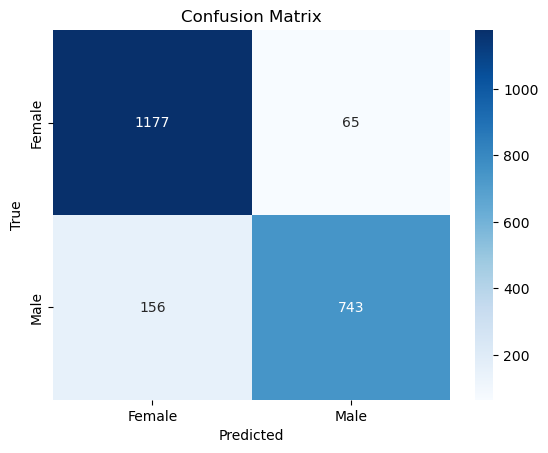

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
confusion = confusion_matrix(true_labels, predicted_labels)

# Print the final confusion matrix
labels = ['Female', 'Male']
sns.heatmap(confusion, annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In sum, even without testing labels, leveraging the validation set for evaluating metrics and generating the confusion matrix can still provide valuable insights into your model's performance.

# Inference on the test set 

Once we have trained our model and obtained satisfactory results, we can use it to make predictions on the test set provided for the challenge. Indeed, the challenge does not provide any test labels making the performance on the validation our only evaluation metric. 

The predictions list will contain the predicted gender labels for the test data.

In [74]:
test_images.shape

(11746, 224, 224)

In [75]:
# Convert the numpy arrays to torch tensors
x_test_tensor = torch.from_numpy(test_images)

# Reshape the tensors to match the expected input shape of the CNN model 
x_test_tensor = x_test_tensor.unsqueeze(1)  # Add a channel dimension

In [76]:
x_test_tensor.shape

torch.Size([11746, 1, 224, 224])

In [77]:
from torch.utils.data import Dataset, DataLoader

# Define your custom dataset class for the test set
class TestDataset(Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        # You can apply any additional transformations to the image if needed
        return image

# Create an instance of the TestDataset
test_dataset = TestDataset(x_test_tensor)

# Create the test data loader
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Note: Why are we not using the `TensorDataset` like we did for the train and val sets?  
  - Because `TensorDataset` is a built-in PyTorch class that wraps two tensors: the features and labels. It works when both inputs and labels are available and aligned. Since the training and validation sets have both, `TensorDataset` works. However, for the test set we do not have any labels. 

In [78]:
import csv

# Create a list to store the predictions
predictions = []

# Iterate over the test dataset
for batch_idx, images in enumerate(test_loader):
    # Move the input data to the device
    images = images.float().to(device)

    # Perform inference by passing the images through the model
    outputs = model(images)

    # Apply softmax to convert the outputs to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Get the predicted gender (0 for female, 1 for male) by selecting the class with the highest probability
    _, predicted = torch.max(probabilities, dim=1)

    # Convert the predicted gender tensor to a list
    predicted = predicted.tolist()

    # Add the predictions to the list
    predictions.extend(predicted)

    ## add the true labels for the confusion matrix  -> we don t have the labels thoughl... so i guess we have to have the confusion matrix for the last epoch of the validation onlt  
    
    ## WHYYY do we have to use the softmax  while we did not use it in the train and val loops??? 

# Generate the output file with image IDs and predicted genders
with open('predictions.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['image_id', 'gender'])
    for image_id, prediction in enumerate(predictions):
        writer.writerow([image_id, prediction])


The file "predictions.csv" will be created in the same directory where the Jupyter Notebook is located. 

In [79]:
# Delete unnecessary variables or tensors
del x_test_tensor
torch.cuda.empty_cache()

End of the challenge. 